call price: 10.450583572185565
put price: 5.573526022256971
parity lhs: 4.877057549928594
parity rhs: 4.877057549928594
delta of call: 0.6368306511756191
delta of put: -0.3631693488243809
gamma: 0.018762017345846895
vega: 37.52403469169379
theta of call: -0.01757267820941972
theta of put: -0.004542138147766099
rho of call: 53.232481545376345
rho of put: -41.89046090469506


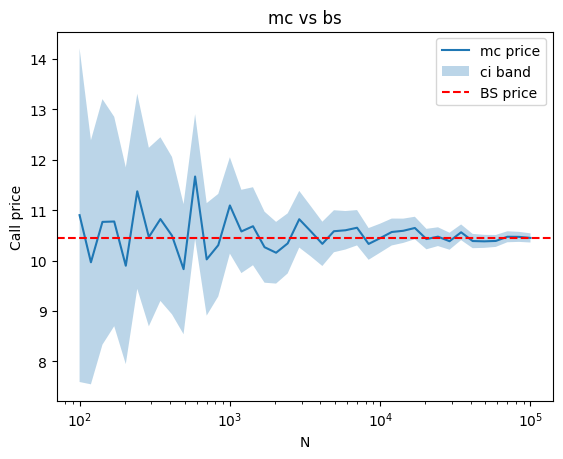

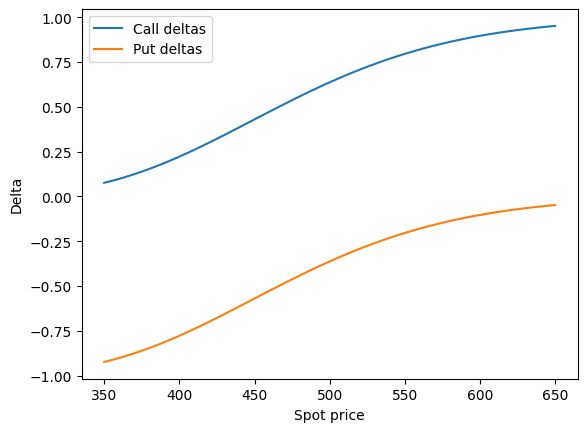

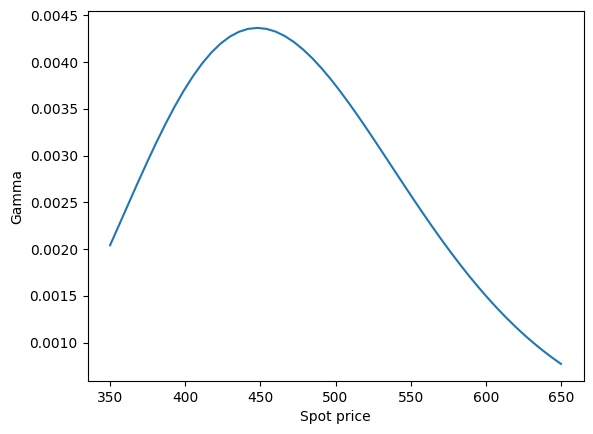

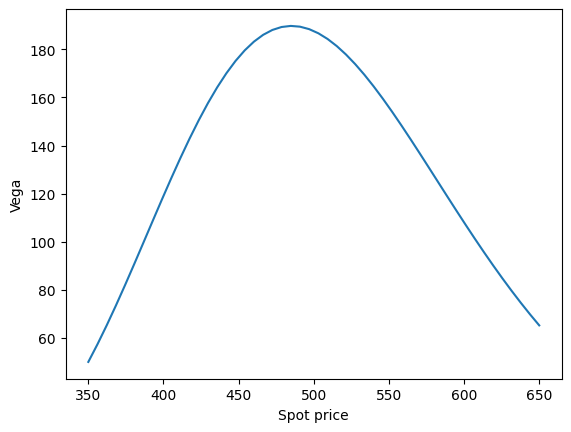

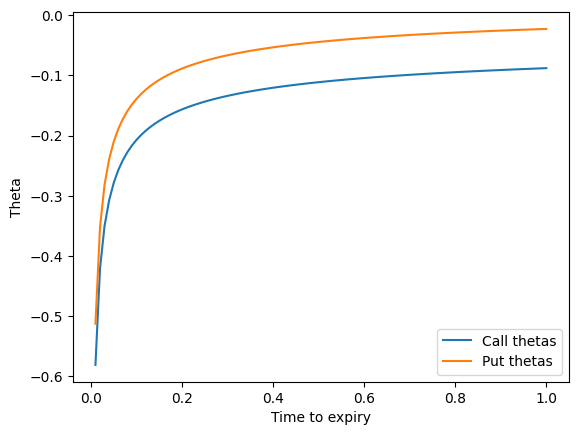

Failed at strike=690, price=77.805: f(a) and f(b) must have different signs


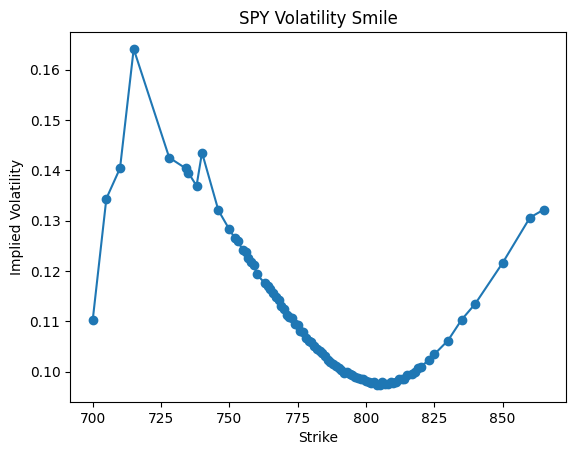

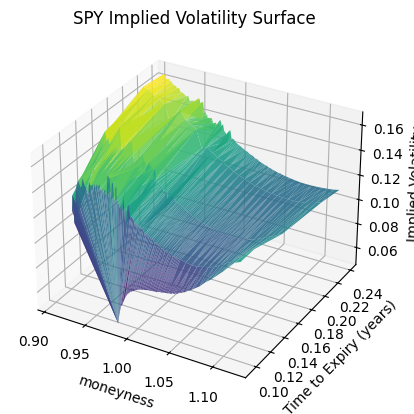

In [20]:
import numpy as np
from scipy import stats, optimize
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd


def compute_d1_d2(S, K, T, r, sigma):
    
    std = sigma * np.sqrt(T)
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / std
    d2 = d1 - std
    return d1, d2, std

def black_scholes(option_type, S, K, T, r, sigma):

    """
    Compute the value of a European option 

    Parameters
    ----------
    option_type : 'call' or 'put'

    S : Current spot price of the underlying.

    K : Strike price.

    T : Time to expiry, in years.

    r : Risk-free interest rate (annualised).

    sigma : Volatility of the underlying (annualised).

    Returns
    -------
    The price of the option

    """


    d1, d2, std = compute_d1_d2(S, K, T, r, sigma)

    if option_type == 'call':

        option_price = S * stats.norm.cdf(d1) - (K * np.exp(-r*T))*stats.norm.cdf(d2)

    elif option_type == 'put':
        
        option_price = (K * np.exp(-r*T))*stats.norm.cdf(-d2) - S * stats.norm.cdf(-d1)

    else:
        raise ValueError(f"option_type must be 'call' or 'put', got '{option_type}'")


    
    return option_price


def val_option(S, K, T, r, sigma):

    """
    Compute the value of a call and put European option, and verify the call put parity

    Parameters
    ----------
    S : Current spot price of the underlying.

    K : Strike price.

    T : Time to expiry, in years.

    r : Risk-free interest rate (annualised).

    sigma : Volatility of the underlying (annualised).

    Returns
    -------
    The price of the call and put option, and the right and left side of the call put parity

    """
    C = black_scholes('call', S, K, T, r, sigma)
    P = black_scholes('put', S, K, T, r, sigma)

    print ('call price:', C)
    print ('put price:', P)


    print ('parity lhs:', C-P)
    print ('parity rhs:', S - K * np.exp(-r*T))

    return C,P







def delta_greek(option_type, S, K, T, r, sigma):

    """
    Compute the delta of a call and put European option

    Parameters
    ----------

    option_type : 'call' or 'put'

    S : Current spot price of the underlying.

    K : Strike price.

    T : Time to expiry, in years.

    r : Risk-free interest rate (annualised).

    sigma : Volatility of the underlying (annualised).

    Returns
    -------
    The delta of the option, the derivative of the option value with respect to S

    """

    d1, d2, std = compute_d1_d2(S, K, T, r, sigma)

    if option_type == 'call':

        delta = stats.norm.cdf(d1)

    elif option_type == 'put':
        
        delta = stats.norm.cdf(d1) - 1
        
    else:
        raise ValueError(f"option_type must be 'call' or 'put', got '{option_type}'")
    
    return delta

def gamma_greek(S, K, T, r, sigma):

    """
    Compute the gamma of a European option (identical for call and put)

    Parameters
    ----------

    S : Current spot price of the underlying.

    K : Strike price.

    T : Time to expiry, in years.

    r : Risk-free interest rate (annualised).

    sigma : Volatility of the underlying (annualised).

    Returns
    -------
    The gamma of the option, the second derivative of the option value with respect to S

    """

    d1, d2, std = compute_d1_d2(S, K, T, r, sigma)

    gamma_calc = (stats.norm.pdf(d1)) /(S*std)

    return gamma_calc

def vega_greek(S, K, T, r, sigma):

    """
    Compute the vega of a European option (identical for call and put)

    Parameters
    ----------

    S : Current spot price of the underlying.

    K : Strike price.

    T : Time to expiry, in years.

    r : Risk-free interest rate (annualised).

    sigma : Volatility of the underlying (annualised).

    Returns
    -------
    The vega of the option, the derivative of the option price with respect to sigma

    """

    d1, d2, std = compute_d1_d2(S, K, T, r, sigma)

    vega_calc = S*stats.norm.pdf(d1)*np.sqrt(T)

    return vega_calc

def theta_greek(option_type, S, K, T, r, sigma):

    """
    Compute the theta of a call and put European option

    Parameters
    ----------

    option_type : 'call' or 'put'

    S : Current spot price of the underlying.

    K : Strike price.

    T : Time to expiry, in years.

    r : Risk-free interest rate (annualised).

    sigma : Volatility of the underlying (annualised).

    Returns
    -------
    The theta of the option, the derivative of the option value with respect to T, or time decay

    """

    d1, d2, std = compute_d1_d2(S, K, T, r, sigma)

    if option_type == 'call':

        theta = -(S*stats.norm.pdf(d1)*sigma)/(2*np.sqrt(T)) - (r*K*np.exp(-r*T)*stats.norm.cdf(d2))

    elif option_type == 'put':

        theta = -(S*stats.norm.pdf(d1)*sigma)/(2*np.sqrt(T)) + (r*K*np.exp(-r*T)*stats.norm.cdf(-d2))

    else:
        raise ValueError(f"option_type must be 'call' or 'put', got '{option_type}'")
    
    return theta/365

def rho_greek(option_type, S, K, T, r, sigma):

    """
    Compute the rho of a call and put European option

    Parameters
    ----------

    option_type : 'call' or 'put'

    S : Current spot price of the underlying.

    K : Strike price.

    T : Time to expiry, in years.

    r : Risk-free interest rate (annualised).

    sigma : Volatility of the underlying (annualised).

    Returns
    -------
    The rho of the option, the derivative of the option value with respect to r, the risk-free rate

    """

    d1, d2, std = compute_d1_d2(S, K, T, r, sigma)

    if option_type == 'call':

        rho = K*T*np.exp(-r*T)*stats.norm.cdf(d2)

    elif option_type == 'put':

        rho = -K*T*np.exp(-r*T)*stats.norm.cdf(-d2)

    else:

        raise ValueError(f"option_type must be 'call' or 'put', got '{option_type}'")
    
    return rho






def greeks_calc(S, K, T, r, sigma):

    """
    Compute all greeks for call and put options

    Parameters
    ----------

    S : Current spot price of the underlying.

    K : Strike price.

    T : Time to expiry, in years.

    r : Risk-free interest rate (annualised).

    sigma : Volatility of the underlying (annualised).

    Returns
    -------
    all greeks for call and put European options

    """

    delta_call = delta_greek('call',S, K, T, r, sigma)
    delta_put = delta_greek('put',S, K, T, r, sigma)
    gamma = gamma_greek(S, K, T, r, sigma)
    vega = vega_greek(S, K, T, r, sigma)
    theta_call = theta_greek('call',S, K, T, r, sigma)
    theta_put = theta_greek('put',S, K, T, r, sigma)
    rho_call = rho_greek('call',S, K, T, r, sigma)
    rho_put = rho_greek('put',S, K, T, r, sigma)

    print ('delta of call:', delta_call)
    print ('delta of put:', delta_put)
    print ('gamma:', gamma)
    print ('vega:', vega)
    print ('theta of call:', theta_call)
    print ('theta of put:', theta_put)
    print ('rho of call:', rho_call)
    print ('rho of put:', rho_put)





            
def price_and_greeks_summary(S, K, T, r, sigma):

    """
    summary of price, call-put parity, and greeks

    Parameters
    ----------

    S : Current spot price of the underlying.

    K : Strike price.

    T : Time to expiry, in years.

    r : Risk-free interest rate (annualised).

    sigma : Volatility of the underlying (annualised).

    Returns
    -------
    all greeks and prices for call and put European options

    """


    val_option(S, K, T, r, sigma)
    greeks_calc(S, K, T, r, sigma)



price_and_greeks_summary(100, 100, 1, 0.05, 0.2)




def monte_carlo_price(option_type, S, K, T, r, sigma, N):

    """
    Compute the price of a call and put European option using monte carlo method
    
    Parameters
    ----------
    
    option_type : 'call' or 'put'
    
    S : Current spot price of the underlying.
    
    K : Strike price.
    
    T : Time to expiry, in years.
    
    r : Risk-free interest rate (annualised).
    
    sigma : Volatility of the underlying (annualised).

    N : number of trials
    
    Returns
    -------
    The price of the option, and its standard error
    
    """

    Z = np.array(np.random.normal(0, 1, N))

    S_T = S * np.exp((r - (sigma**2)/2)*T+ sigma*np.sqrt(T)*Z)

    if option_type == 'call':

        payoff = np.maximum(S_T - K, 0)

    elif option_type == 'put':

        payoff = np.maximum(K - S_T, 0)

    else:
        raise ValueError(f"option_type must be 'call' or 'put', got '{option_type}'")
    
    discounted_payoff = payoff * np.exp(-r*T)

    mc_price = np.mean(discounted_payoff)

    SE = np.std(discounted_payoff) / np.sqrt(N)

    return mc_price, SE

monte_carlo_price('call', 100, 100, 1, 0.05, 0.2, 100000)

N_values = np.logspace(2,5,40).astype(int)


def MC_BS_convergence(S, K, T, r, sigma, N_values):

    """
    Compute the confidence interval bounds and prices for a european call option
    
    Parameters
    ----------
    
    S : Current spot price of the underlying.
    
    K : Strike price.

    T : Time to expiry, in years.
    
    r : Risk-free interest rate (annualised).
    
    sigma : Volatility of the underlying (annualised).

    N_values : number of trials for monte carlo prices
    
    Returns
    -------
    The CI band bounds, and a list of prices of the options
    
    """

    prices = []
    ci_uppers = []
    ci_lowers = []


    for N in N_values:

        price, se = monte_carlo_price('call', S, K, T, r, sigma, N)
        prices.append(price)
        ci_uppers.append(price + 1.96*se)
        ci_lowers.append(price - 1.96*se)

    return prices, ci_uppers, ci_lowers


def plot_convergence(prices, ci_uppers, ci_lowers, N_values, bs_price):

    """
    Plot the convergence between monte carlo and black scholes prices
    
    Parameters
    ----------
    
    prices : monte carlo price
    
    ci_uppers : upper bound of confidence interval
    
    ci_lowers : lower bound of confidence interval

    N_values : number of trials for monte carlo prices

    bs_price : black scholes price
    
    Returns
    -------
    A plot of the bs and mc price and the confidence interval
    
    """

    plt.plot(N_values, prices, label = 'mc price')
    plt.fill_between(N_values, ci_lowers, ci_uppers, alpha = 0.3, label = 'ci band')
    plt.axhline(bs_price, color = 'red', linestyle = '--', label = 'BS price')

    plt.xscale('log')

    plt.xlabel('N')
    plt.ylabel('Call price')
    plt.title('mc vs bs')
    plt.legend()

    plt.show()


bs_price = black_scholes('call', 100, 100, 1, 0.05, 0.2)
prices, ci_uppers, ci_lowers = MC_BS_convergence(100, 100, 1, 0.05, 0.2, N_values)

plot_convergence(prices, ci_uppers, ci_lowers, N_values, bs_price)


spot_range = np.linspace(350, 650, 50)
T_range = np.linspace(0.01, 1, 100)

def delta_vs_spot(spot_range, K, T, r, sigma):

    call_deltas = [delta_greek('call', s, K, T, r, sigma) for s in spot_range]
    put_deltas = [delta_greek('put', s, K, T, r, sigma) for s in spot_range]

    plt.plot(spot_range, call_deltas, label = 'Call deltas')
    plt.plot(spot_range, put_deltas, label = 'Put deltas')

    plt.xlabel('Spot price')
    plt.ylabel('Delta')

    plt.legend()

    plt.show()

def gamma_vs_spot(spot_range, K, T, r, sigma):

    gammas = [gamma_greek(s, K, T, r, sigma) for s in spot_range]

    plt.plot(spot_range, gammas)

    plt.xlabel('Spot price')
    plt.ylabel('Gamma')

    plt.show()

def vega_vs_spot(spot_range, K, T, r, sigma):

    vegas = [vega_greek(s, K, T, r, sigma) for s in spot_range]

    plt.plot(spot_range, vegas)

    plt.xlabel('Spot price')
    plt.ylabel('Vega')

    plt.show()

def theta_vs_T(T_range, S, K, r, sigma):

    call_thetas = [theta_greek('call',S, K, t, r, sigma) for t in T_range]
    put_thetas = [theta_greek('put',S, K, t, r, sigma) for t in T_range]

    plt.plot(T_range, call_thetas, label = 'Call thetas')
    plt.plot(T_range, put_thetas, label = 'Put thetas')

    plt.xlabel('Time to expiry')
    plt.ylabel('Theta')

    plt.legend()

    plt.show()





    
def greek_plots():

    delta_vs_spot(spot_range, 500, 1, 0.05, 0.2)
    gamma_vs_spot(spot_range, 500, 1, 0.05, 0.2)
    vega_vs_spot(spot_range, 500, 1, 0.05, 0.2)
    theta_vs_T(T_range, 500, 500, 0.05, 0.2)

greek_plots()



def calc_IV(option_type, V, S, K, T, r):

    def price_diff(sigma):
        return black_scholes(option_type, S, K, T, r, sigma) - V

    implied_vol = optimize.brentq(price_diff, 0.001, 5)

    return implied_vol


V = black_scholes('call', 100, 100, 1, 0.05, 0.25)
IV = calc_IV('call', V, 100, 100, 1, 0.05)



def plot_vol_smile(calls, S, expiry, r):

    ivs = []
    valid_strikes = []
    
    mid_prices = (calls['bid'] + calls['ask']) / 2
    strikes = calls['strike']

    for v,k in zip(mid_prices, strikes):
        try:
            iv = calc_IV('call', v, S, k, expiry, r)
            ivs.append(iv)
            valid_strikes.append(k)

        except ValueError as e:
            print(f"Failed at strike={k}, price={v}: {e}")

    
    
    plt.plot(valid_strikes, ivs, marker='o')
    plt.xlabel('Strike')
    plt.ylabel('Implied Volatility')
    plt.title('SPY Volatility Smile')
    plt.show()
    


calls = pd.read_csv('spy_calls_oct9.csv')
expiry = 37/365




plot_vol_smile(calls, 764.59, expiry, 0.05)

T1 = 35/365
T2 = 42/365
T3 = 56/365
T4 = 77/365
T5 = 87/365

calls1 = pd.read_csv('spy_calls_oct9.csv')
calls2 = pd.read_csv('spy_calls_oct16.csv')
calls3 = pd.read_csv('spy_calls_oct30.csv')
calls4 = pd.read_csv('spy_calls_nov20.csv')
calls5 = pd.read_csv('spy_calls_nov30.csv')

expiries_data = [
    (T1, calls1),
    (T2, calls2),
    (T3, calls3),
    (T4, calls4),
    (T5, calls5)
]

def iv_surface(expiries_data, S, r):

    all_moneyness = []
    all_Ts = []
    all_ivs = []

    for T, calls in expiries_data:
        mid_prices = (calls['bid'] + calls['ask']) / 2
        strikes = calls['strike']

        for v, k in zip(mid_prices, strikes):
            if k < 700 or k > 865:
                continue

            try:
                iv = calc_IV('call', v, S, k, T, r)
                all_moneyness.append(k/S)
                all_Ts.append(T)
                all_ivs.append(iv)
            except ValueError:
                continue


    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot_trisurf(all_moneyness, all_Ts, all_ivs, cmap='viridis', edgecolor='none', alpha=0.9)
    ax.set_xlabel('moneyness')
    ax.set_ylabel('Time to Expiry (years)')
    ax.set_zlabel('Implied Volatility')
    ax.set_title('SPY Implied Volatility Surface')
    plt.show()



iv_surface(expiries_data, 771.30, 0.05)







15